#### 1. Vad kännetecknar klassificeringsproblem? Ge några exempel på tillämpningsområden.
Målvariabeln är en kategori istället för ett tal. Modellen har antingen rätt eller fel. Exempel: spamfilter, bedrägeridetektering, medicinsk diagnos, bildigenkänning.

#### 2. Förklara hur OvR- och OvO-algoritmerna fungerar.
OvR tränar en binär modell per klass som skiljer den från alla andra — 10 modeller vid 10 klasser. OvO tränar en modell per par av klasser — 45 modeller vid 10 klasser — och klassen med flest röster vinner.

#### 3. Förklara följande utvärderingsmått:
- a. Confusion matrix är en tabell med verkliga klasser mot predikterade. Diagonalen är rätt svar, resten visar vilka fel modellen gör.
- b. Accuracy är andelen rätt. Vilseledande vid obalanserade klasser.
- c. Precision är andelen av de flaggade som verkligen var positiva.
- d. Recall är andelen av de verkligt positiva som modellen hittade.
- e. F1 är det harmoniska medelvärdet av precision och recall, och blir bara högt om båda är höga.
- f. ROC-kurvan visar recall mot andelen falsklarm för alla tröskelvärden. AUC sammanfattar: 1 är perfekt, 0,5 är slump.

#### 4. Vad är precision-recall tradeoff för något?
Ett tröskelvärde avgör vad som räknas som positivt. Höjer man tröskeln blir det färre falsklarm (högre precision) men fler missar (lägre recall). Sänker man den blir det tvärtom. Man kan inte maximera båda samtidigt.

#### 5. Några vanligt förekommande modeller för klassificeringsproblem är enligt nedan. Förklara översiktligt hur respektive modell fungera.
- a. Logistisk regression beräknar en linjär kombination av variablerna och skickar den genom sigmoidfunktionen, som ger en sannolikhet mellan 0 och 1. Beslutsgränsen blir alltid rak.
- b. SVC söker den beslutsgräns som ger största marginal till närmaste punkterna. Kernel-tricket ger icke-linjära gränser.
- c. Beslutsträd delar upp datan med ja/nej-frågor, men löven innehåller klasser istället för medelvärden.
- d. VotingClassifier kombinerar olika modeller genom majoritetsröstning eller medelvärde av sannolikheter. BaggingClassifier tränar samma modell på olika urval.
- e. Random forest är bagging av träd med slumpmässigt urval av variabler vid varje delning. Prediktionen är majoritetsrösten.
- f. Extra trees är som random forest men drar även tröskelvärdena slumpmässigt istället för att söka det bästa. Snabbare och med lägre varians.

#### 6. Vad innebär det att vi kan kolla på feature importance med hjälp av trädmodeller såsom beslutsträd eller random forest?
Trädmodeller mäter hur mycket varje variabel bidrar till att minska orenheten över alla delningar. Det visar vilka variabler modellen faktiskt använder, vilket är användbart för variabelselektion och för att förklara modellen. Men det säger inte något om orsakssamband.

#### 7. Stina säger till Kalle på lunchsamtalet “jag vill ha högsta möjliga precision för vår klassificieringsmodell”
Recall skulle bli sämre. Detta kan vara bra i situationer där vi verkligen vill undvika falskt negativa resultat. Det betyder att vi vill vara säkra på att när modellen säger att något är positivt, så ska det faktiskt vara positivt. Detta kan vara viktigt vid exempelvis en domstolsdom. Om modellen skulle användas för att avgöra om någon är skyldig, skulle det vara viktigare att undvika att döma en oskyldig person än att missa en person som faktiskt är skyldig.

#### 8. Förklara hur man kan tolka figur 4.8 på sidan 175.
 Figuren visar hur logistisk regression delar upp observationerna i olika klasser. Punkterna visar de verkliga klasserna, medan bakgrundsfärgen visar hur stor sannolikhet modellen ger för klass 1. Gränsen går vid 50 % sannolikhet. Gränsen är rak eftersom logistisk regression inte kan skapa böjda gränser. Punkter nära gränsen är de som modellen är mest osäker på.

#### 9. På sidan 209 står det “på träningsdatan använder vi .fit_transform(), på valideringsdatan och testdatan använder vi endast .transform().” Förklara logiken bakom detta.

En transformer lär sig något i .fit() — StandardScaler lär sig medelvärde och standardavvikelse. På träningsdatan används fit_transform(), på validering och test bara transform(), så att samma värden används. Annars läcker information från testdatan in, och ny data skulle skalas på ett annat sätt än den data modellen tränats på.

#### 11. Förklara koden.
Koden jämför fem verkliga klasser med fem prediktioner. Class 0 predikterades två gånger varav en rätt (precision 0,50) och den enda verkliga hittades (recall 1,00). Class 1 missades helt. Class 2 predikterades två gånger, båda rätt (precision 1,00), men två av tre hittades (recall 0,67). Accuracy blev 0,60. Med bara fem observationer är siffrorna väldigt känsliga.

#### 13. Komplett ML-flöde — hr_employee_data.xlsx, y = left

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

hr = pd.read_excel("../data/hr_employee_data.xlsx").drop(columns="Emp_Id")

# salary är ordinal, Department är nominal
hr["salary"] = hr["salary"].map({"low": 0, "medium": 1, "high": 2})
hr = pd.get_dummies(hr, columns=["Department"], drop_first=True, dtype=int)

X = hr.drop(columns="left")
y = hr["left"]
print(X.shape, f"Andel som slutat: {y.mean():.1%}")

(14999, 17) Andel som slutat: 23.8%


In [2]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full)

print(len(X_train), len(X_val), len(X_test))

8999 3000 3000


Emp_Id tas bort — ett ID har ingen förklaringskraft. salary är ordinal och 
kodas 0/1/2, Department är nominal och dummy-kodas.

stratify=y ser till att andelen som slutat (23,8 %) blir densamma i alla tre 
seten. Viktigt vid obalanserade klasser.

In [3]:
# Logistisk regression kräver skalning
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

log_reg = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

for name, model, Xv in [("Logistisk regression", log_reg, X_val_s),
                        ("Random Forest", rf, X_val)]:
    p = model.predict(Xv)
    print(f"{name}: accuracy {accuracy_score(y_val, p):.3f}, "
          f"precision {precision_score(y_val, p):.3f}, "
          f"recall {recall_score(y_val, p):.3f}, "
          f"F1 {f1_score(y_val, p):.3f}")

Logistisk regression: accuracy 0.794, precision 0.607, recall 0.378, F1 0.466
Random Forest: accuracy 0.991, precision 0.996, recall 0.968, F1 0.982


Random Forest är överlägsen: F1 0,98 mot 0,47. Logistisk regression hittar bara 
38 % av de som slutar.

Förklaringen syns i EDA:n från kapitel 3. Sambanden är icke-linjära — till exempel 
U-mönstret för antal projekt, där både 2 och 6–7 projekt ger många avhopp. En 
linjär modell kan inte fånga det, ett träd kan dela upp det i intervall.

Här används F1 och recall snarare än accuracy, eftersom klasserna är obalanserade. 
En modell som alltid gissar "stannar" skulle få 76 % accuracy utan att vara till nytta.

Accuracy:  0.991
Precision: 0.996
Recall:    0.965
F1:        0.980


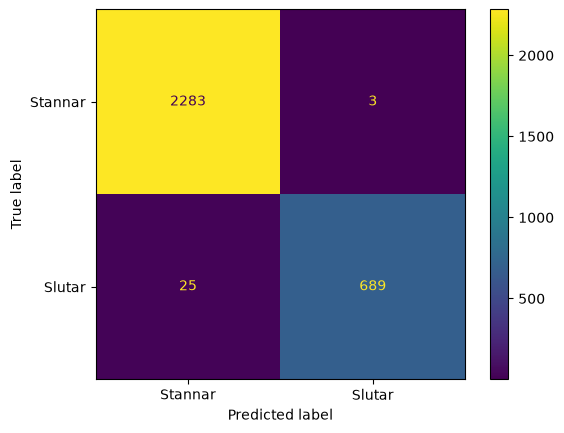

In [4]:
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_full, y_train_full)
pred_test = final_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, pred_test):.3f}")
print(f"Precision: {precision_score(y_test, pred_test):.3f}")
print(f"Recall:    {recall_score(y_test, pred_test):.3f}")
print(f"F1:        {f1_score(y_test, pred_test):.3f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test),
                       display_labels=["Stannar", "Slutar"]).plot()
plt.show()

In [5]:
importances = pd.Series(final_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(8).round(3).to_string())

satisfaction_level      0.311
number_project          0.190
time_spend_company      0.184
average_montly_hours    0.153
last_evaluation         0.124
salary                  0.012
Work_accident           0.007
Department_technical    0.004


På testdatan: accuracy 0,99, precision 1,00, recall 0,96, F1 0,98.

Confusion matrix: av 714 som slutade hittade modellen 689, och 25 missades. 
Bara 3 av 2 286 som stannade flaggades felaktigt.

Viktigaste variablerna: satisfaction_level, number_project, time_spend_company, 
average_montly_hours och last_evaluation. Samma variabler som stack ut i EDA:n. 
Lön och avdelning spelar liten roll för modellen.

För ett företag är recall det viktigaste måttet — en missad avhoppare kostar mer 
än ett onödigt samtal med någon som tänkte stanna.

Förbehåll: datan innehåller cirka 3 000 rader som är identiska i allt utom 
Emp_Id. Identiska rader kan hamna i både tränings- och testdata, vilket kan 
göra resultatet något för optimistiskt.

#### 15. Prediktera egna handskrivna siffror med en MNIST-modell

In [6]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler

mnist = fetch_openml("mnist_784", version=1, cache=True, as_frame=False)

X_mnist = mnist["data"][:10000]
y_mnist = mnist["target"][:10000].astype(np.uint8)

print(X_mnist.shape, y_mnist.shape)
print("Pixelvärden:", X_mnist.min(), "-", X_mnist.max())

(10000, 784) (10000,)
Pixelvärden: 0 - 255


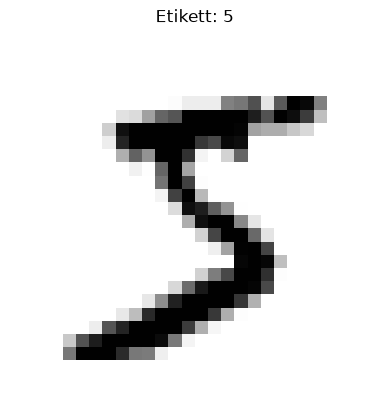

In [7]:
# Titta på en siffra ur datan
plt.imshow(X_mnist[0].reshape(28, 28), cmap="binary")
plt.title(f"Etikett: {y_mnist[0]}")
plt.axis("off")
plt.show()

In [8]:
scaler_mnist = StandardScaler()
X_scaled = scaler_mnist.fit_transform(X_mnist)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_mnist, test_size=2000, random_state=40)

mnist_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
mnist_model.fit(X_tr, y_tr)

print(f"Accuracy på testdata: {mnist_model.score(X_te, y_te):.4f}")

Accuracy på testdata: 0.9510


Extra Trees valdes eftersom den presterade bäst i bokens jämförelse i 
kodexemplet. Modellen får cirka 95 % accuracy på MNIST-testdatan.

Notera att pixlarna skalas med StandardScaler. Det innebär att även mina egna 
bilder måste skalas med exakt samma scaler innan prediktion — med transform(), 
inte fit_transform().

In [9]:
from PIL import Image, ImageOps

def preprocess(path):
    """Gör om ett foto av en handskriven siffra till MNIST-format."""
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)    # rätta mobilens rotation
    img = img.convert("L")                # gråskala
    img = ImageOps.invert(img)            # vit siffra på svart bakgrund
    arr = np.array(img, dtype=np.float32)

    # ta bort bakgrundsbrus och skuggor
    arr[arr < arr.max() * 0.5] = 0

    # beskär till siffrans kanter
    rows = np.where(arr.any(axis=1))[0]
    cols = np.where(arr.any(axis=0))[0]
    arr = arr[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]

    # skala till 20 pixlar på längsta sidan, behåll proportionerna
    h, w = arr.shape
    s = 20 / max(h, w)
    small = Image.fromarray(arr.astype(np.uint8)).resize(
        (max(1, round(w * s)), max(1, round(h * s))))
    small = np.array(small, dtype=np.float32)

    # centrera i en 28x28-ruta
    canvas = np.zeros((28, 28), dtype=np.float32)
    dh, dw = small.shape
    top, left = (28 - dh) // 2, (28 - dw) // 2
    canvas[top:top + dh, left:left + dw] = small

    # samma värdeintervall som MNIST (0-255)
    canvas = canvas / canvas.max() * 255

    return canvas.reshape(1, -1)

In [10]:
import os

folder = "bilder"
files = sorted(f for f in os.listdir(folder)
               if f.lower().endswith((".jpg", ".jpeg", ".png")))
print(files)

['3.jpg', '7.jpg']


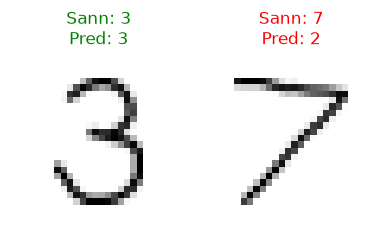

1 av 2 rätt


In [11]:
fig, axs = plt.subplots(1, len(files), figsize=(2 * len(files), 2.5))
axs = np.atleast_1d(axs)
correct = 0

for ax, f in zip(axs, files):
    x = preprocess(os.path.join(folder, f))
    x_scaled = scaler_mnist.transform(x)          # samma scaler som träningen
    pred = mnist_model.predict(x_scaled)[0]

    true = int(os.path.splitext(f)[0])
    correct += pred == true

    ax.imshow(x.reshape(28, 28), cmap="binary")
    ax.set_title(f"Sann: {true}\nPred: {pred}",
                 color="green" if pred == true else "red")
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"{correct} av {len(files)} rätt")

Förbehandlingen gör om fotot steg för steg så att det liknar MNIST-datan:

1. Rättar rotationen, eftersom mobilbilder sparas med en rotationsflagga
2. Gråskala, eftersom MNIST har en kanal istället för tre
3. Inverterar — MNIST har vit siffra på svart bakgrund, fotot är tvärtom
4. Nollar pixlar under halva maxvärdet för att ta bort papperets struktur och skuggor
5. Beskär till siffran
6. Skalar till 20 pixlar med bibehållna proportioner, så att en etta inte blir bred
7. Centrerar i en 28x28-ruta
8. Skalar till värdeintervallet 0–255, som MNIST

Sedan skalas bilden med samma StandardScaler som träningsdatan.

**Resultat:** [1 av 2 rätt]

Vanliga felkällor: för tunn penna (siffran försvinner nästan vid nedskalningen), 
ojämn belysning som lämnar kvar skuggor, och att MNIST består av amerikansk 
handstil — en etta med flagga eller en sjua med tvärstreck finns knappt i 
träningsdatan.